In [ ]:
import kagglehub

# Download latest version => https://www.kaggle.com/datasets/ouaraskhelilrafik/tp-02-audio
path = kagglehub.dataset_download("ouaraskhelilrafik/tp-02-audio")

print("Path to dataset files:", path)

In [1]:
import os
import random
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio


# --- Définir le dossier contenant les fichiers audio ---
data_path = os.path.join('data','audio', 'Data (ESC-10)', 'Data (ESC-10)', '003 - Sea waves')
audio_files = [f for f in os.listdir(data_path) if f.endswith(".ogg")]

# --- Choisir un fichier au hasard ---
file = random.choice(audio_files)
file_path = os.path.join(data_path, file)
Audio(file_path)

In [3]:
# --- Charger l'audio ---
y, sr = librosa.load(file_path, sr=None)  
print("Duration (s):", round(len(y)/sr, 2))

Duration (s): 5.0


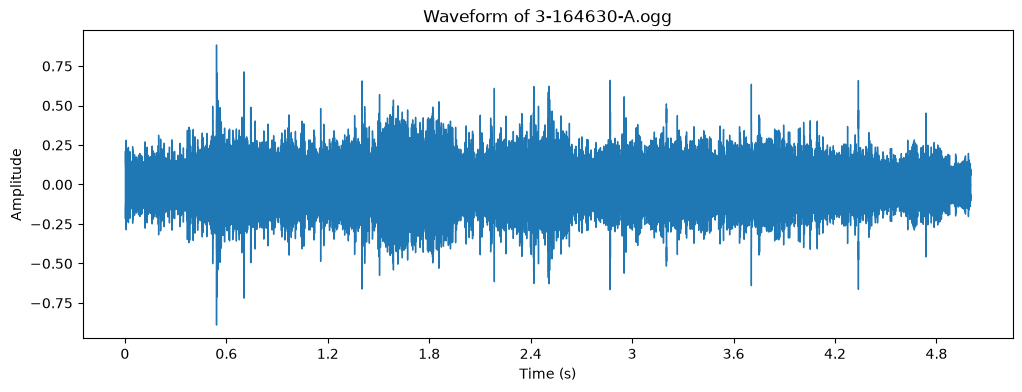

In [7]:
# --- Afficher le waveform ---
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title(f"Waveform of {file}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

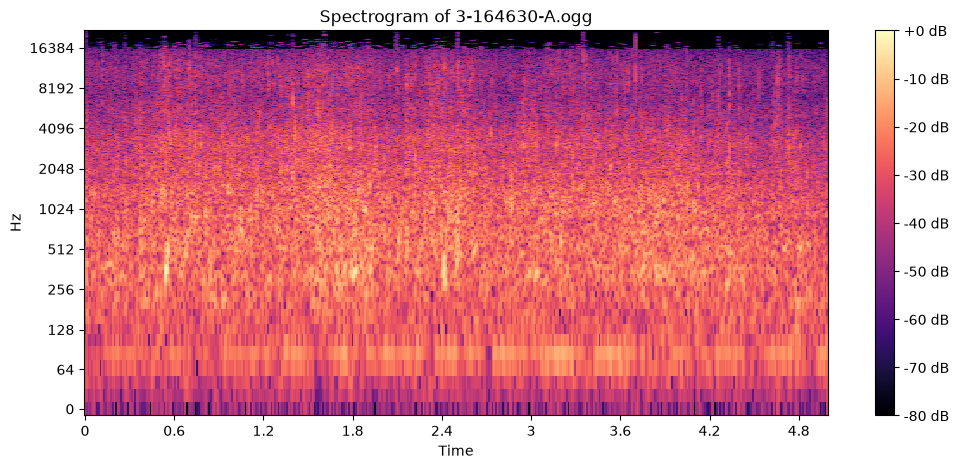

In [8]:
# --- Spectrogramme ---
D = np.abs(librosa.stft(y))
DB = librosa.amplitude_to_db(D, ref=np.max)

plt.figure(figsize=(12, 5))
librosa.display.specshow(DB, sr=sr, x_axis="time", y_axis="log")
plt.colorbar(format="%+2.0f dB")
plt.title(f"Spectrogram of {file}")
plt.show()


### Rajouter du bruit

In [5]:
noise = np.random.normal(0, 0.05, len(y))
y_noisy = y + noise

Audio(y_noisy, rate=sr)

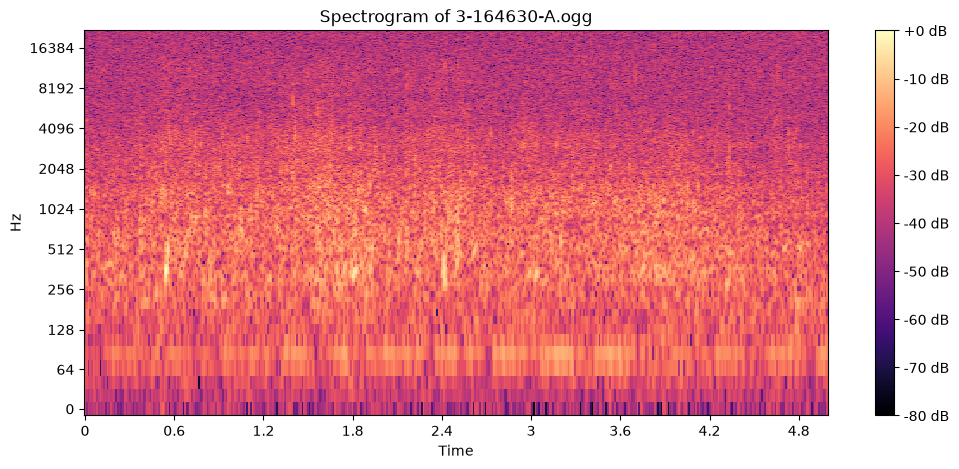

In [9]:
# --- Spectrogramme ---
D = np.abs(librosa.stft(y_noisy))
DB = librosa.amplitude_to_db(D, ref=np.max)

plt.figure(figsize=(12, 5))
librosa.display.specshow(DB, sr=sr, x_axis="time", y_axis="log")
plt.colorbar(format="%+2.0f dB")
plt.title(f"Spectrogram of {file}")
plt.show()
